# Down-sampling fidelity: comparing coarse-graining methods against 512² DNS

**No model training.** We generate a full-resolution ($512^2$) Kolmogorov DNS trajectory with
the project's own spectral solver, then ask a purely *data* question: when we coarse-grain
$512\to64$, how faithful is each method to the DNS ground truth? This isolates the
down-sampler from any model, and sets the *ceiling* any downstream surrogate could reach.

All heavy lifting is in **`downsample_eval.py`** (DNS generation + metrics, reusing
`dataset_viz`); this notebook loads the cached results and presents them. Companion to
`divergence_explainer.ipynb`, which explains the mechanisms.

### Methods (all $512\to64$)

| method | filter | divergence-free? | spectrum |
|---|---|---|---|
| `velocity_bilinear` | bilinear on velocity (current default) | ✗ | aliased |
| `vorticity_bilinear_recon` | bilinear on **vorticity**, reconstruct velocity | ✓ | aliased |
| `velocity_spectral` | sharp low-pass on velocity (`_downsample_spectral`) | ✓ | **exact** |
| `vorticity_spectral_recon` | sharp low-pass on vorticity, reconstruct | ✓ | exact (≡ above) |
| `velocity_smooth_spectral` | raised-cosine taper, then truncate | ✓ | attenuated top band |

## Method & metrics

- **Ground truth** is the $512^2$ DNS velocity at each snapshot (averaged over 4 samples × 48
  snapshots per Re, after warm-up).
- **`velocity_spectral` is the reference for field error**: it is the orthogonal projection
  $P_{64}W$ onto the resolved modes — the $L_2$-optimal band-limited field — so its field error
  is $0$ *by construction*. That is the correct statement that it is optimal, not a bias; the
  spectrum metric below is scored against the DNS directly and needs no such reference.
- **Metrics:**
  - **divergence** $\|\nabla\!\cdot\!\mathbf u\|/\omega_{\rm rms}$ — incompressibility.
  - **energy spectrum** $E(k)$ vs the DNS spectrum — exposes **aliasing** (high-$k$ inflation).
  - **resolved-band rel-$L_2$** and **correlation** vs $P_{64}W$ — how far the coarse field is
    from the optimal band-limited representation.
  - **vorticity range** — *would* expose **Gibbs** overshoot of a sharp cut (on this
    well-resolved data it shows there is essentially none — see the closing notes).

**An important framing number:** at these Reynolds numbers only a tiny fraction of the DNS
energy lives above the coarse Nyquist ($k>32$) — see the table. So $64^2$ *can* represent this
flow well; the differences below are **corruption of the resolved band**, not lost sub-grid
energy. (The radial spectrum's last bin over-counts on the coarse grid, so plots/ratios stop at
$k\approx30$.)

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import dataset_viz as dv

res = torch.load("downsample_eval_results.pt", weights_only=False)
RES   = sorted(res)                       # [1000, 8000]
ORDER = res[RES[0]]["method_order"]
LABELS = {
    "velocity_bilinear":        "velocity bilinear (current)",
    "vorticity_bilinear_recon": "vorticity bilinear → recon",
    "velocity_spectral":        "velocity spectral (= projection)",
    "vorticity_spectral_recon": "vorticity spectral → recon",
    "velocity_smooth_spectral": "velocity smooth-spectral",
}
COLORS = {"velocity_bilinear": "tab:red", "vorticity_bilinear_recon": "tab:orange",
          "velocity_spectral": "black", "vorticity_spectral_recon": "tab:green",
          "velocity_smooth_spectral": "tab:blue"}
STYLE  = {"velocity_bilinear": "-", "vorticity_bilinear_recon": "-",
          "velocity_spectral": "-", "vorticity_spectral_recon": "--",
          "velocity_smooth_spectral": "-"}

# To regenerate from scratch (needs the GPU + solver, ~25 s):
#   import downsample_eval as de
#   res = {Re: de.run_analysis(Re, n_snapshots=48, stride_steps=256, batch_size=4) for Re in (1000, 8000)}
for Re in RES:
    r = res[Re]
    print(f"Re{Re}: DNS div/omega={r['dns_div_ratio']:.1e} | "
          f"{100*r['irreducible_frac']:.3f}% of energy above coarse Nyquist k={r['ns']//2} "
          f"(lost by ALL methods) | {r['batch_size']} samples × {r['n_snapshots']} snapshots")

Re1000: DNS div/omega=1.0e-05 | 0.004% of energy above coarse Nyquist k=32 (lost by ALL methods) | 4 samples × 48 snapshots
Re8000: DNS div/omega=9.9e-06 | 0.024% of energy above coarse Nyquist k=32 (lost by ALL methods) | 4 samples × 48 snapshots


In [2]:
def alias_ratio(r, nm, klo=24, khi=30):   # mean E_method/E_DNS over the upper resolved band
    k = r["k"]; Edns = r["E_dns"][:len(k)]; m = (k >= klo) & (k <= khi)
    return float(np.mean(r["methods"][nm]["E"][m] / Edns[m]))

for Re in RES:
    r = res[Re]
    print(f"\n################  Re{Re}")
    print(f"{'method':30s} {'div/omega':>10s} {'relL2_vs_proj':>13s} {'corr':>8s} "
          f"{'alias E@k24-30':>14s} {'vort range':>18s}")
    print("-" * 100)
    for nm in ORDER:
        m = r["methods"][nm]
        print(f"{LABELS[nm]:30s} {m['div_ratio']:10.1e} {100*m['relL2_vs_ref']:12.2f}% "
              f"{m['corr_vs_ref']:8.4f} {alias_ratio(r, nm):14.2f} "
              f"[{m['vmin']:7.1f},{m['vmax']:7.1f}]")


################  Re1000
method                          div/omega relL2_vs_proj     corr alias E@k24-30         vort range
----------------------------------------------------------------------------------------------------
velocity bilinear (current)       4.0e-02        11.75%   0.9931           1.07 [  -28.8,   27.2]
vorticity bilinear → recon        1.1e-06        11.78%   0.9930           1.17 [  -28.5,   26.8]
velocity spectral (= projection)    1.0e-06         0.00%   1.0000           1.00 [  -28.7,   27.3]
vorticity spectral → recon        1.1e-06         0.00%   1.0000           1.00 [  -28.7,   27.3]
velocity smooth-spectral          1.1e-06         1.06%   0.9999           0.08 [  -28.7,   26.4]

################  Re8000
method                          div/omega relL2_vs_proj     corr alias E@k24-30         vort range
----------------------------------------------------------------------------------------------------
velocity bilinear (current)       9.2e-02        12.21% 

## 1. Energy spectrum — aliasing

Top row: $E(k)$ for each method over the DNS spectrum. Bottom row: the ratio $E_{\rm method}/E_{\rm DNS}$
on the resolved band. Bilinear methods **rise above 1** toward Nyquist (energy folded down from
unresolved scales); the sharp-spectral methods sit exactly on $1$; the smooth filter **dips
below 1** (it attenuates the top of the resolved band rather than aliasing it).

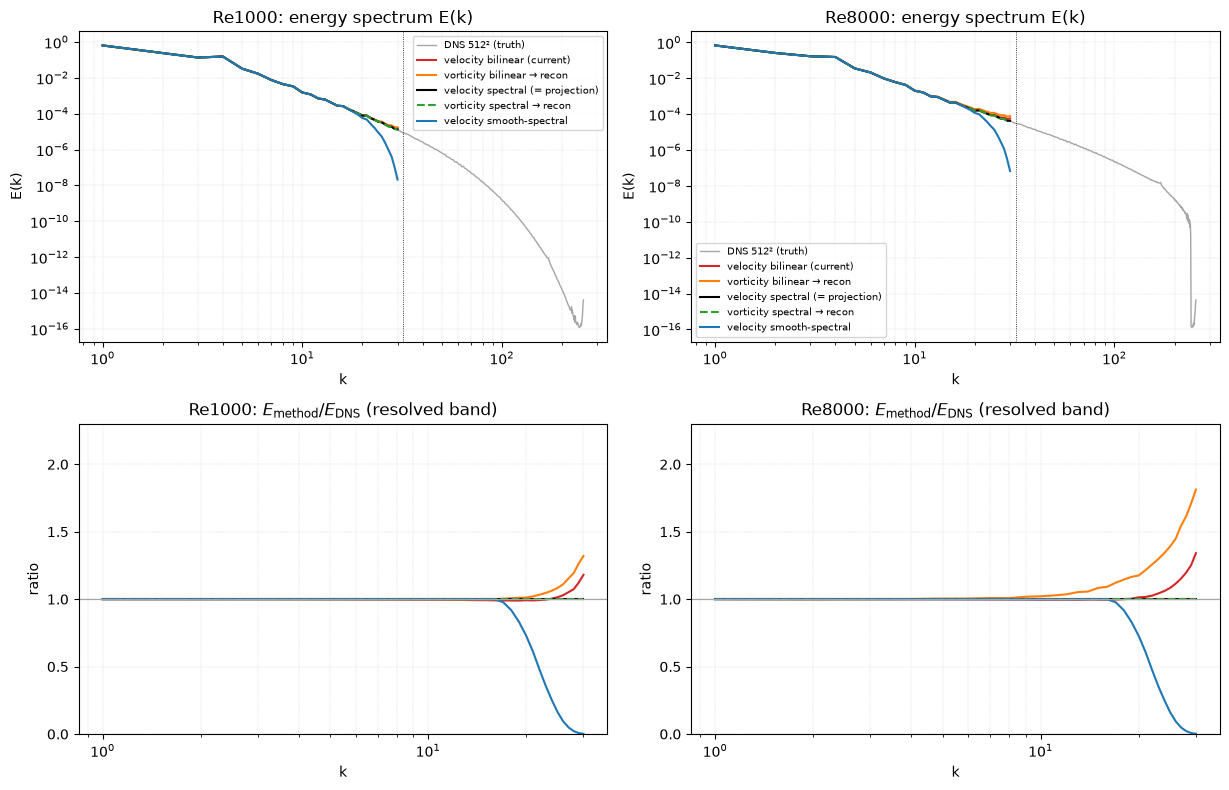

In [3]:
fig, axes = plt.subplots(2, len(RES), figsize=(6.2 * len(RES), 8))
for j, Re in enumerate(RES):
    r = res[Re]; k = r["k"]; kd = r["k_dns"]; Edns_full = r["E_dns"]; Edns = Edns_full[:len(k)]
    kmaxp = r["ns"] // 2 - 2
    mask = (k >= 1) & (k <= kmaxp)
    ax = axes[0, j]
    ax.loglog(kd[(kd >= 1)], Edns_full[(kd >= 1)], color="0.65", lw=1.0, label="DNS 512² (truth)")
    for nm in ORDER:
        ax.loglog(k[mask], r["methods"][nm]["E"][mask], lw=1.5,
                  color=COLORS[nm], ls=STYLE[nm], label=LABELS[nm])
    ax.axvline(r["ns"] // 2, color="k", lw=0.6, ls=":")
    ax.set_title(f"Re{Re}: energy spectrum E(k)"); ax.set_xlabel("k"); ax.set_ylabel("E(k)")
    ax.grid(True, which="both", ls="--", lw=0.3, alpha=0.5); ax.legend(fontsize=7)
    ax = axes[1, j]
    for nm in ORDER:
        ax.semilogx(k[mask], r["methods"][nm]["E"][mask] / Edns[mask], lw=1.5,
                    color=COLORS[nm], ls=STYLE[nm], label=LABELS[nm])
    ax.axhline(1.0, color="0.65", lw=0.9); ax.set_ylim(0, 2.3)
    ax.set_title(f"Re{Re}: $E_{{\\rm method}}/E_{{\\rm DNS}}$ (resolved band)")
    ax.set_xlabel("k"); ax.set_ylabel("ratio"); ax.grid(True, which="both", ls="--", lw=0.3, alpha=0.5)
fig.tight_layout()

## 2. Divergence and resolved-band field error

Left: incompressibility — bilinear-on-velocity is the only method that isn't divergence-free,
and it worsens with Re; every **reconstruct** path and every spectral path is at machine
precision. Right: distance from the optimal band-limited field ($P_{64}W$) — the spectral
projection is $0$ by definition; bilinear (either form) sits ~12–13%; the smooth filter is
close in $L_2$ (the modes it attenuates carry little energy) even though its *spectrum* is
wrong in the top band.

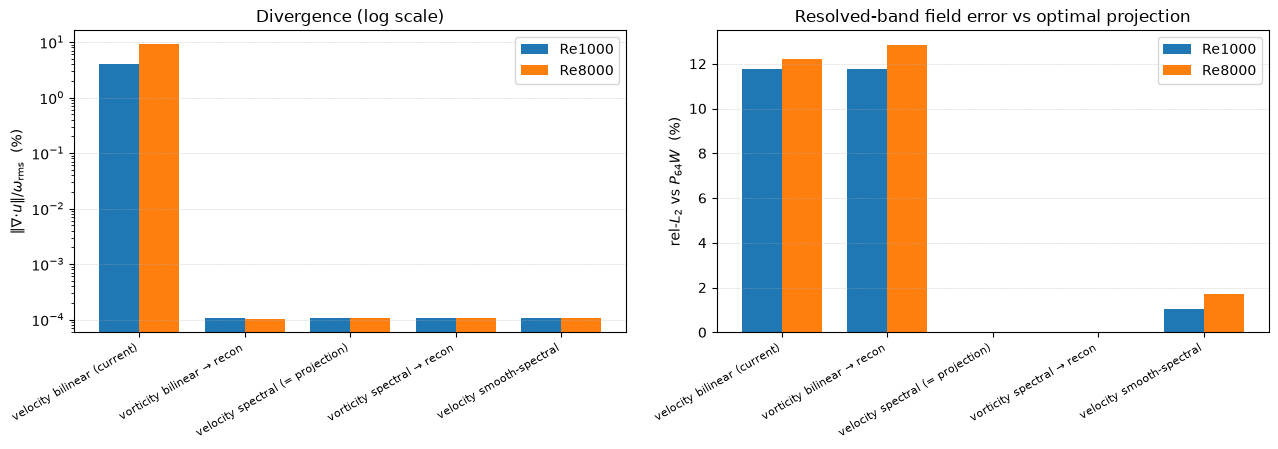

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
x = np.arange(len(ORDER)); w = 0.38
for i, Re in enumerate(RES):
    div = [100 * res[Re]["methods"][nm]["div_ratio"] for nm in ORDER]
    axes[0].bar(x + (i - 0.5) * w, div, w, label=f"Re{Re}")
axes[0].set_yscale("log"); axes[0].set_ylabel(r"$\|\nabla\!\cdot\!u\|/\omega_{\rm rms}$  (%)")
axes[0].set_title("Divergence (log scale)")
for i, Re in enumerate(RES):
    rl = [100 * res[Re]["methods"][nm]["relL2_vs_ref"] for nm in ORDER]
    axes[1].bar(x + (i - 0.5) * w, rl, w, label=f"Re{Re}")
axes[1].set_ylabel("rel-$L_2$ vs $P_{64}W$  (%)")
axes[1].set_title("Resolved-band field error vs optimal projection")
for ax in axes:
    ax.set_xticks(x); ax.set_xticklabels([LABELS[nm] for nm in ORDER], rotation=30, ha="right", fontsize=8)
    ax.grid(True, axis="y", ls="--", lw=0.4, alpha=0.6); ax.legend()
fig.tight_layout()

## 3. Real space (Re8000, one snapshot)

DNS vorticity vs each coarse field. Bilinear looks smoothed but carries aliased high-$k$
texture; the spectral cut matches the DNS large scales; the smooth filter is visibly softer at
small scales.

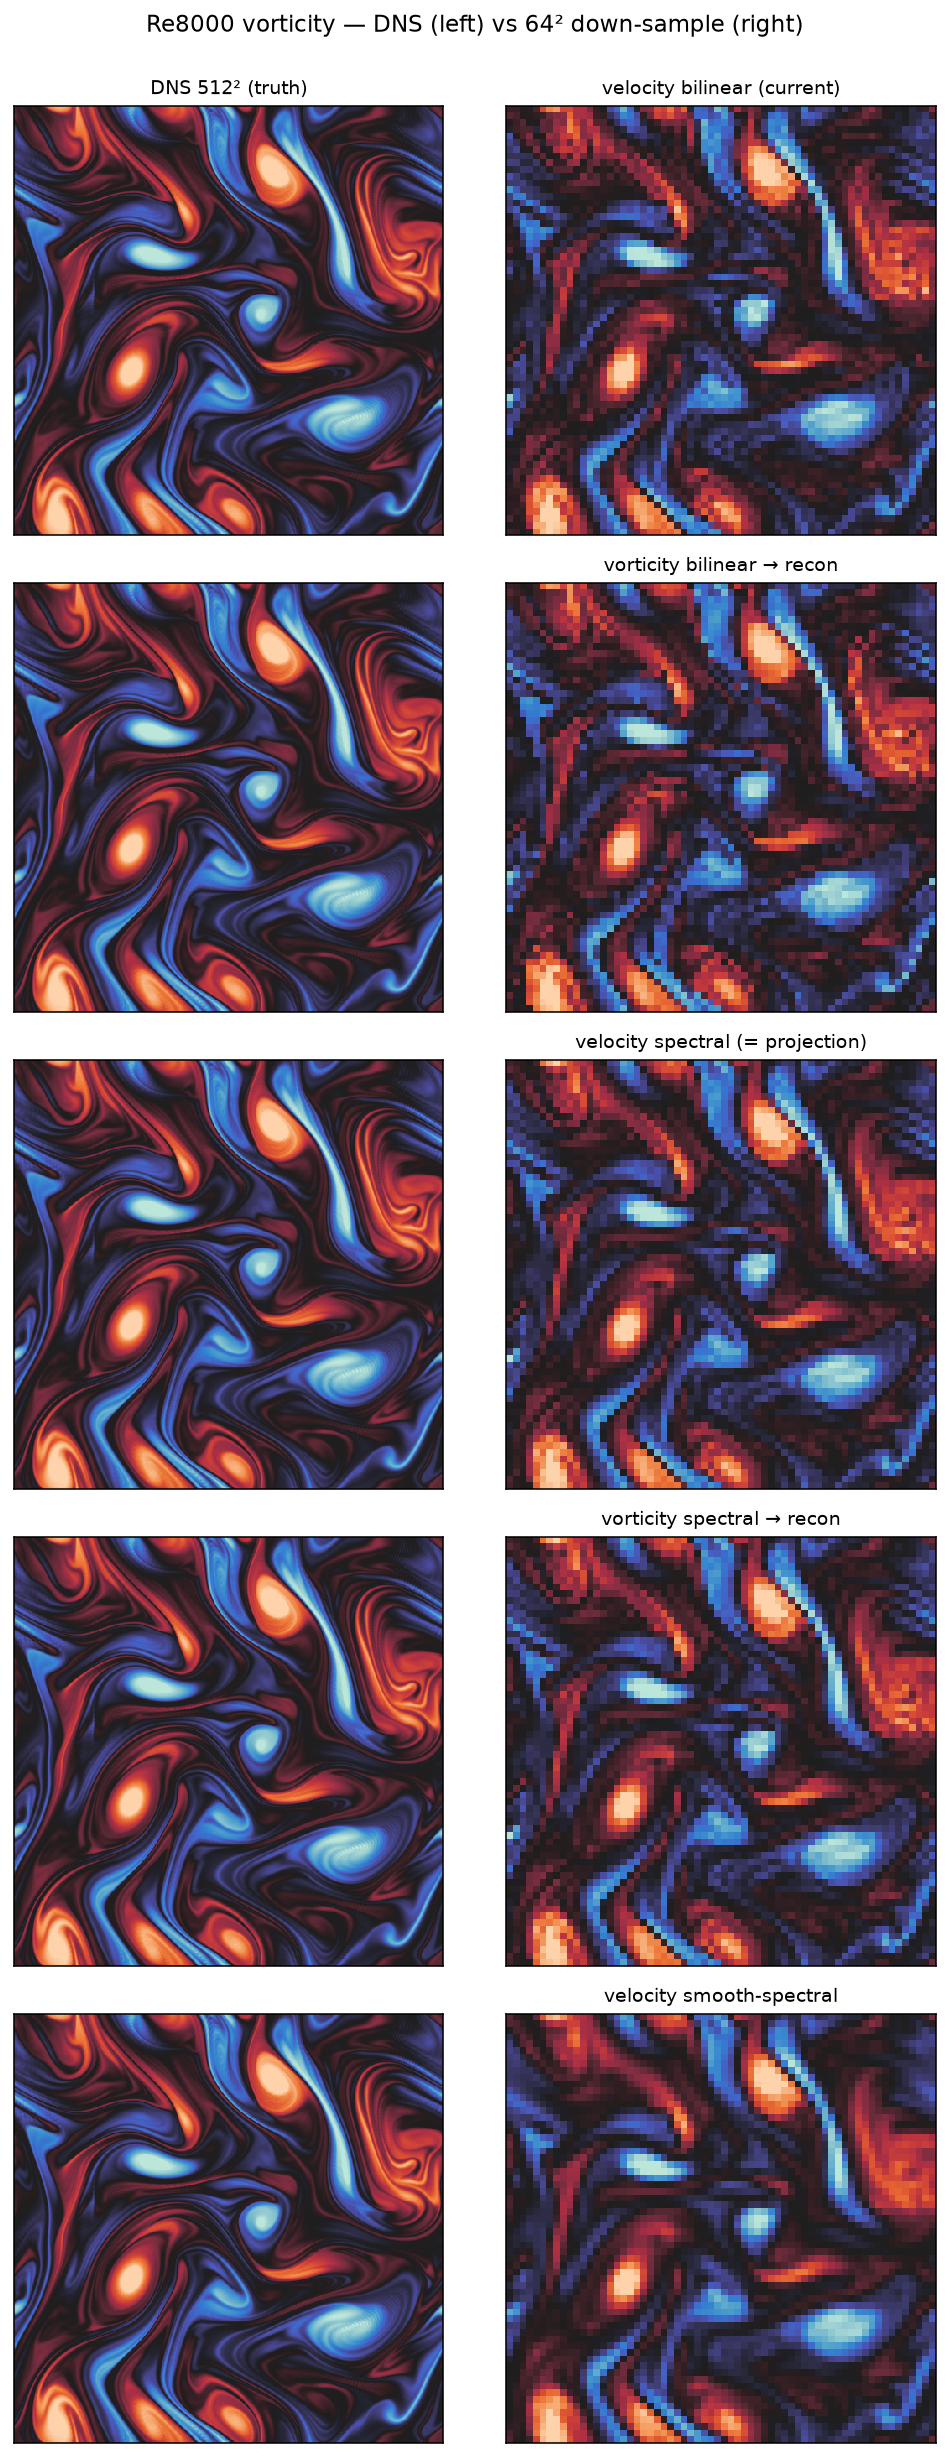

In [5]:
Re = RES[-1]; r = res[Re]; f = r["fields"]
dns = f["dns_omega"]
vmax = float(np.percentile(np.abs(dns), 99))
fig, axes = plt.subplots(len(ORDER), 2, figsize=(7.5, 3.5 * len(ORDER)), dpi=140)
for row, nm in enumerate(ORDER):
    axes[row, 0].imshow(dns, cmap=dv._cmap(), vmin=-vmax, vmax=vmax, interpolation="nearest")
    axes[row, 1].imshow(f["methods_omega"][nm], cmap=dv._cmap(), vmin=-vmax, vmax=vmax,
                        interpolation="nearest")
    axes[row, 1].set_title(LABELS[nm], fontsize=10)
    for c in (0, 1):
        axes[row, c].set_xticks([]); axes[row, c].set_yticks([])
axes[0, 0].set_title("DNS 512² (truth)", fontsize=10)
fig.suptitle(f"Re{Re} vorticity — DNS (left) vs 64² down-sample (right)", y=1.0, fontsize=12)
fig.tight_layout()

## What the data says

- **Divergence-free is decoupled from the filter.** Reconstructing velocity from down-sampled
  vorticity is at machine precision *regardless* of the filter (bilinear or spectral) —
  confirming §6 of the explainer. `velocity_bilinear` is the only non-solenoidal method, and it
  degrades with Re (4%→9%).
- **Bilinear aliases; the sharp cut is exact.** The ratio plot shows bilinear inflating the
  high-$k$ band (the part a spectrum-faithful model like PDE-Refiner most cares about), while
  `velocity_spectral` reproduces every resolved mode exactly. `vorticity_spectral_recon`
  overlaps it exactly — the consistency check that vorticity-space and velocity-space sharp
  filtering are the same operator.
- **The artifacts are corruption, not loss.** Almost none of the energy is above the coarse
  Nyquist here, so a faithful coarse-graining loses essentially nothing; bilinear's ~12% field
  error is self-inflicted by aliasing.
- **Gibbs is negligible on this data.** The sharp-cut vorticity range is no larger than
  bilinear's — because the flow is well-resolved at $64^2$ (the spectrum has decayed long before
  Nyquist). Gibbs ringing only bites for *under-resolved / sharp* fields (the top-hat demo in the
  explainer); here the sharp spectral cut has essentially no real-space downside. That removes
  the main caveat against it for this dataset.

### Choosing a down-sampler by downstream task
- **Forecasting / rollout:** a *wrong* high-$k$ spectrum (aliasing) is the dangerous artifact;
  prefer a **spectral** filter, leaning **smooth** to avoid ringing that can amplify over a
  rollout.
- **Super-resolution $64\to512$:** the recoverable band must be preserved at full amplitude, so
  the **sharp** spectral cut is best (unit-gain, identity inverse on the resolved modes). The
  smooth filter's top-band attenuation (ratio < 1 above) would force an ill-conditioned
  deconvolution.
- **Either way:** down-sample in **vorticity → reconstruct velocity** for free incompressibility,
  with a **spectral** filter. The single best general-purpose choice is the sharp spectral cut;
  switch to a smooth taper only if rollout ringing proves harmful.

*Next step (involves training): drop a 1M-param model on one trajectory per method and measure
one-step MSE, high-correlation rollout time, and per-$k$ spectrum drift — the data ceilings
above predict the ordering.*